job_location
Anywhere         69552
Singapore        23415
Paris, France    12311
Name: count, dtype: int64

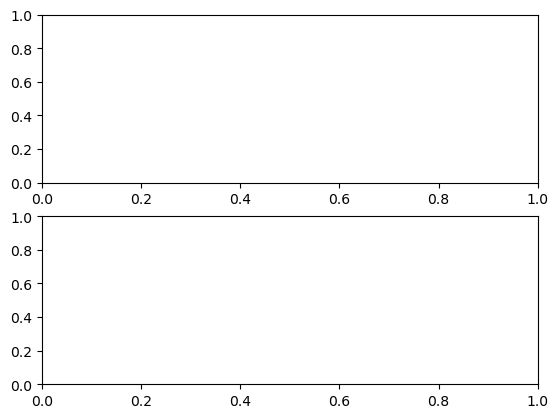

In [15]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

fig, ax = plt.subplots(2, 1)

top3_job_locations = df['job_location'].value_counts().head(3)
top3_job_locations

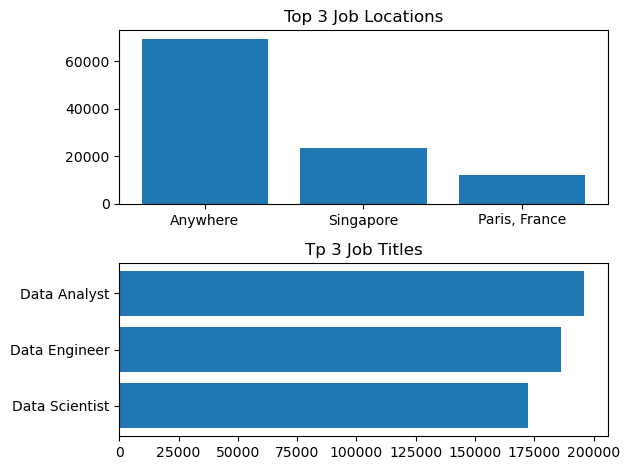

In [2]:
fig, ax = plt.subplots(2, 1)
top3_job_locations = df['job_location'].value_counts().head(3)
ax[0].bar(top3_job_locations.index, top3_job_locations.values)
ax[0].set_title('Top 3 Job Locations')

top3_job_titles = df['job_title_short'].value_counts().head(3)
ax[1].barh(top3_job_titles.index, top3_job_titles.values)
ax[1].set_title('Tp 3 Job Titles')
ax[1].invert_yaxis()

fig.tight_layout()
plt.show()

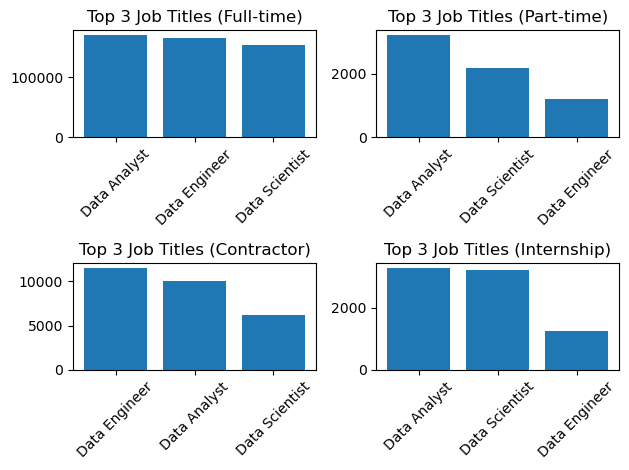

In [13]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

fig, ax = plt.subplots(2, 2)

# Job schedule types
schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']

for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type'] == schedule]
    job_titles = df_schedule['job_title_short'].value_counts().head(3)
    ax[i//2, i%2].bar(job_titles.index, job_titles.values)
    ax[i//2, i%2].tick_params(axis = 'x', rotation=45)
    ax[i//2, i%2].set_title(f'Top 3 Job Titles ({schedule})')

fig.tight_layout()
plt.show()

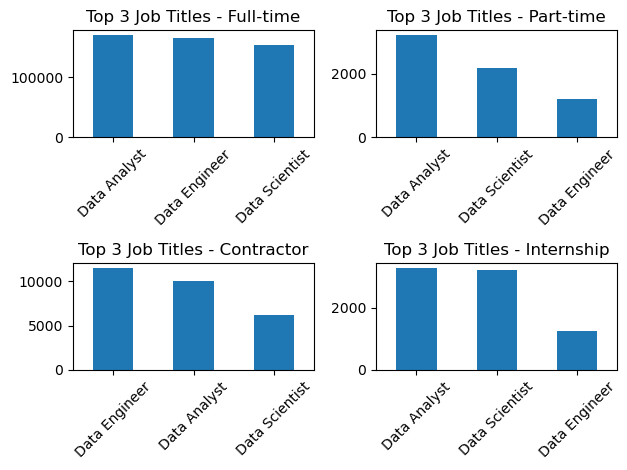

In [12]:
schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']

fig, ax = plt.subplots(2, 2)
ax = ax.flatten()

for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type']== schedule]
    top_job_titles = df_schedule['job_title_short'].value_counts().head(3).plot(kind='bar', ax=ax[i])
    ax[i].set_title(f"Top 3 Job Titles - {schedule}")
    ax[i].tick_params(axis = 'x', rotation=45)
    ax[i].set_xlabel('')


fig.tight_layout()
plt.show()

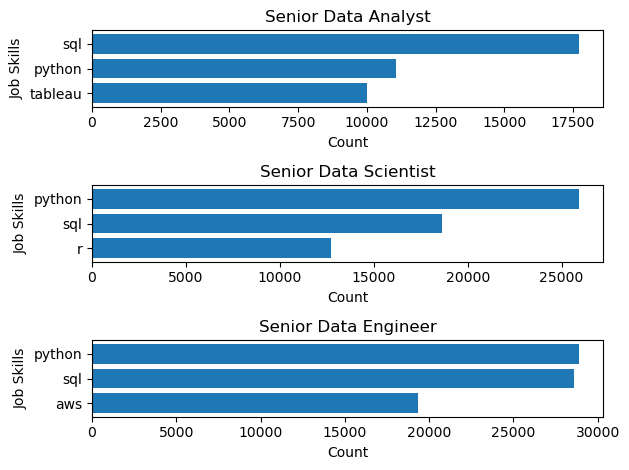

In [14]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_skills = df.explode('job_skills')
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
fig, ax = plt.subplots(len(job_roles), 1)
for i, role in enumerate(job_roles):
    role_skills = df_skills[df_skills['job_title_short'] == role]['job_skills'].value_counts().head(3)
    ax[i].barh(role_skills.index, role_skills.values)
    ax[i].set_title(role)
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('Job Skills')
    ax[i].invert_yaxis()
fig.tight_layout()
plt.show()

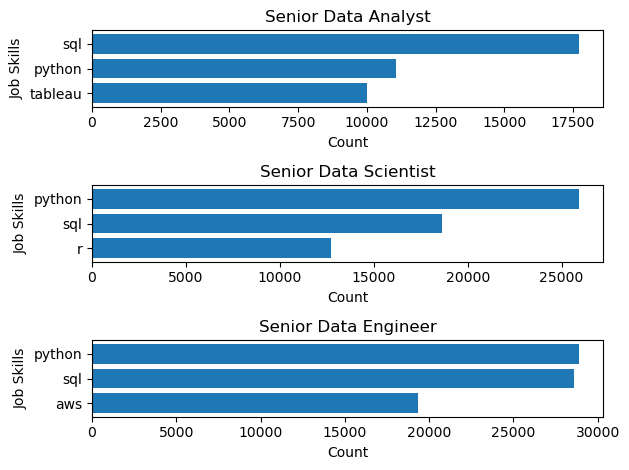

In [18]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_skills = df.explode('job_skills')
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
fig, ax = plt.subplots(3,1)
for i, role in enumerate(job_roles):
    role_skills = df_skills[df_skills['job_title_short'] == role]['job_skills'].value_counts().head(3)
    ax[i].barh(role_skills.index, role_skills.values)
    ax[i].set_title(role)
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('Job Skills')
    ax[i].invert_yaxis()
fig.tight_layout()
plt.show()